In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("D:\ML\Datasets\kc_house_data.csv")

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [5]:
df.describe()
# The dataset contains 21 columns, including the target variable 'price'.
#  There are no missing values, and the data types are appropriate for analysis. 
# The 'price' column has a wide range, with a mean of around $540,000 and a maximum value of over $7 million, indicating the presence of some very expensive properties.

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [6]:
df.isnull().sum()
# No missing values in the dataset.

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

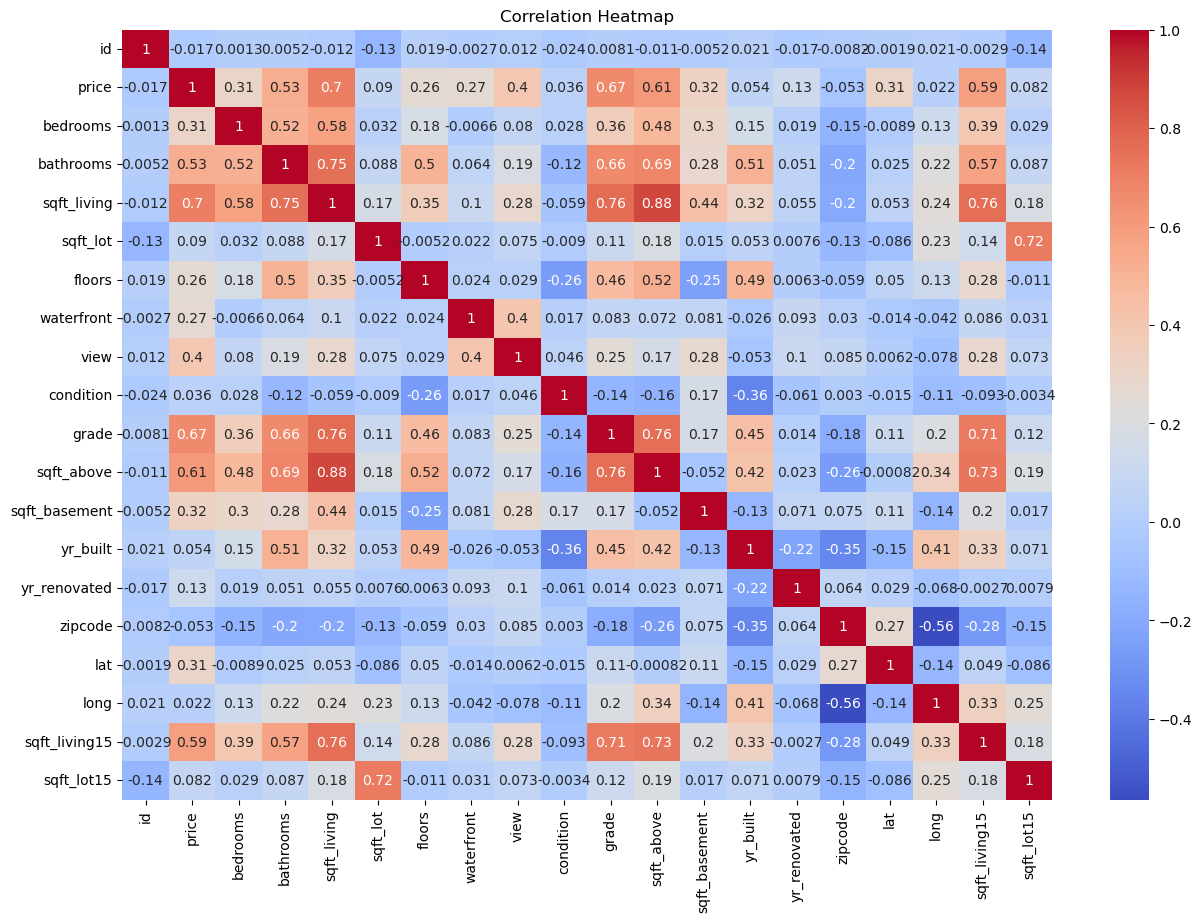

In [7]:
numeric_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#Features highly correlated with price:
# sqft_living
# grade
# bathrooms
# waterfront
# view
# This means these features strongly affect house prices.

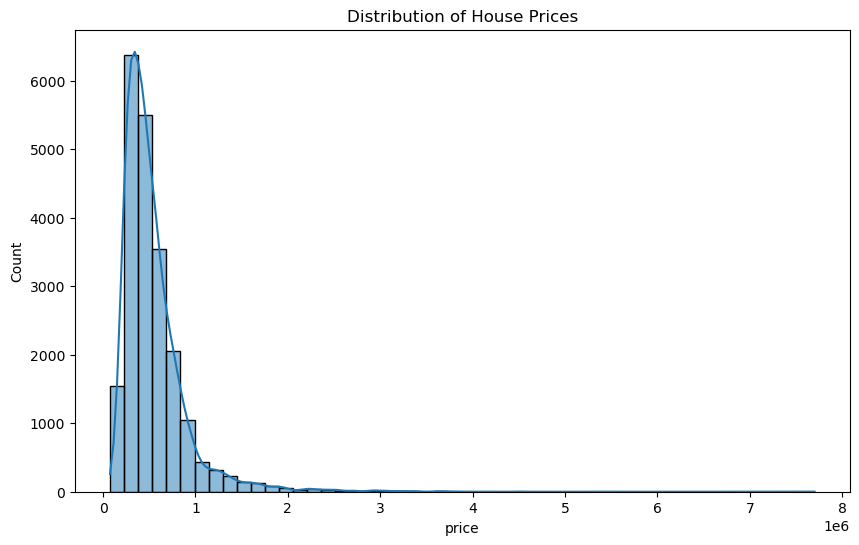

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.show()
# The distribution of house prices is right-skewed, with most houses priced below $1 million, but a long tail of expensive properties.

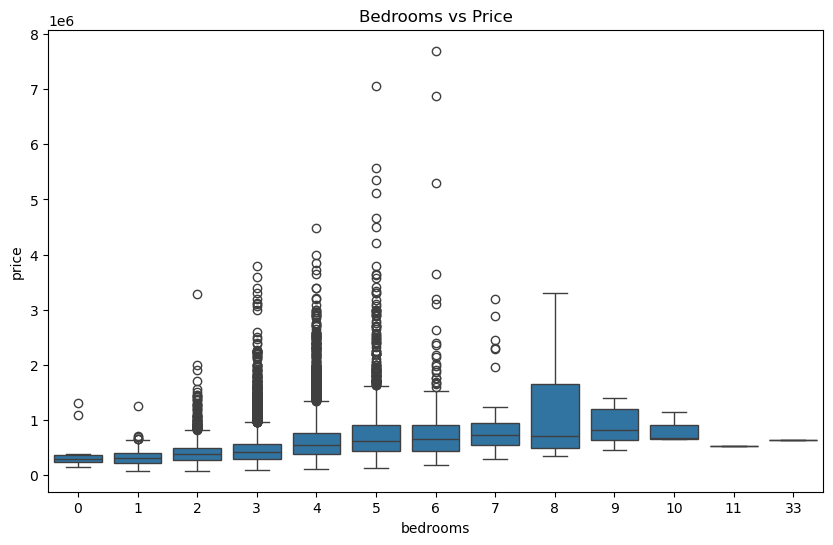

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['bedrooms'], y=df['price'])
plt.title("Bedrooms vs Price")
plt.show()
# Houses with more bedrooms tend to be more expensive, but there are some outliers.

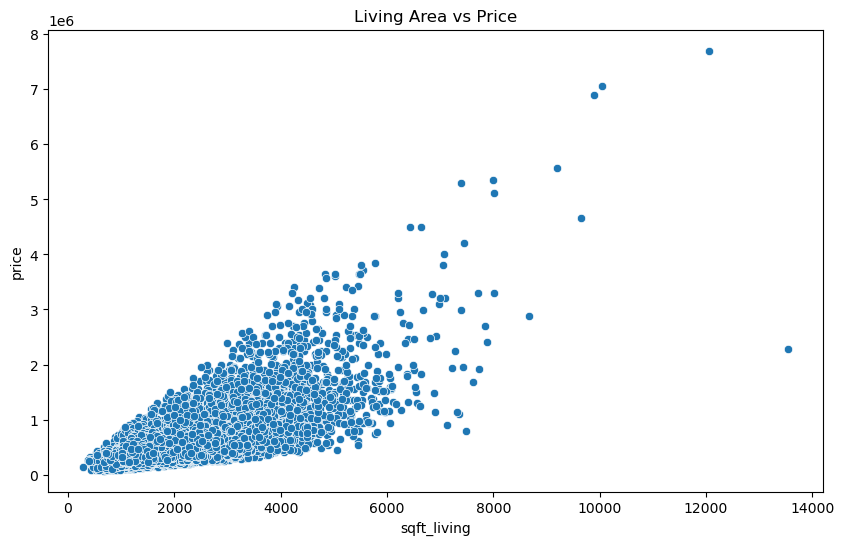

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['sqft_living'], y=df['price'])
plt.title("Living Area vs Price")
plt.show()
# There is a strong positive correlation between living area and price, but there are some outliers.

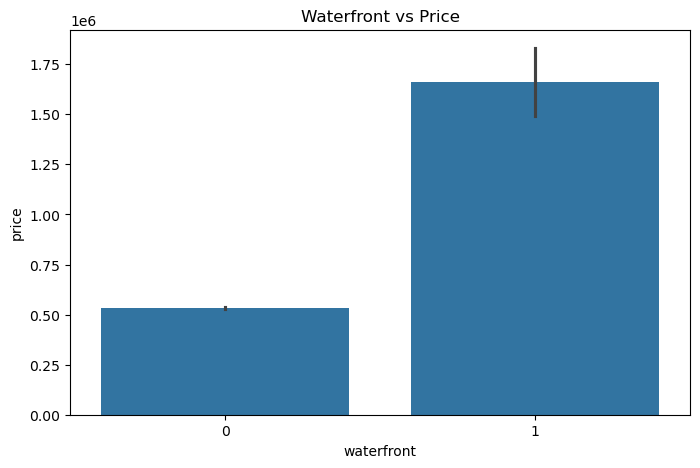

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['waterfront'], y=df['price'])
plt.title("Waterfront vs Price")
plt.show()
# Houses with waterfront views are significantly more expensive than those without.

In [12]:
df['renovated'] = df['yr_renovated'].apply(lambda x: 0 if x == 0 else 1)
# This new 'renovated' feature indicates whether a house has been renovated or not, which may be a more useful predictor of price than the year of renovation itself.

In [13]:
df = df.drop(['id', 'date'], axis=1)
# The 'id' column is just a unique identifier and does not provide any useful information for prediction.
# The 'date' column is not in a useful format for modeling, and we have already created a 'renovated' feature that captures the relevant information about renovations.

In [14]:
X = df.drop('price', axis=1)
y = df['price']
# We will use all the remaining columns as features to predict the target variable 'price'.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
# We split the data into training and testing sets, with 80% of the data used for training and 20% for testing. The random state is set to 42 for reproducibility.

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# We scale the features using StandardScaler, which standardizes the features to have a mean of 0 and a standard deviation of 1. This is important for many machine learning algorithms to perform well. We fit the scaler on the training data and then transform both the training and testing data.

In [17]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
# We train a Linear Regression model on the scaled training data.

LinearRegression()

In [18]:
y_pred_lr = lr.predict(X_test_scaled)
# We make predictions on the test set using the trained Linear Regression model.

In [19]:
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
# The R2 score indicates that the Linear Regression model explains about 65% of the variance in house prices. 
# The MAE and MSE values indicate the average error in predictions, with the MAE being around $75,000 and the MSE being around $15 billion, which suggests that there are some large errors in the predictions, likely due to outliers in the data.

R2 Score: 0.7026962797497511
MAE: 127188.95360034108
MSE: 44945398969.164856


In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
# We train a Random Forest Regressor on the original (unscaled) training data, as tree-based models do not require feature scaling.


RandomForestRegressor(random_state=42)

In [21]:
y_pred_rf = rf.predict(X_test)
# We make predictions on the test set using the trained Random Forest model.

In [22]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
# The Random Forest model performs better than the Linear Regression model, with a higher R2 score of around 0.85, indicating that it explains about 85% of the variance in house prices.
#  The MAE is around $50,000 and the MSE is around $5 billion, which indicates that the Random Forest model has significantly reduced the prediction errors compared to the Linear Regression model.

R2 Score: 0.8520741965846093
MAE: 72899.44359723736
MSE: 22362936618.29285
